In [21]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

import matplotlib.pyplot as plt

import tensorflow as tf 
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [2]:
train_df = pd.read_csv("/kaggle/input/competitions/nlp-getting-started/train.csv")
train_df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


## Data Processing

First I will try to see the information about the dataset

In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


From the information, it seems that there are only 2 columns that are valueable for the training. Thus I will drop other columns.

In [4]:
train_df.drop(columns=["id", "keyword", "location"], inplace=True)

Since I have cleaned the data, now it's time to split it for training

In [5]:
X = train_df["text"]
y = train_df["target"]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

Next I will see the word count of the each tweet, this will be useful for the tokenization

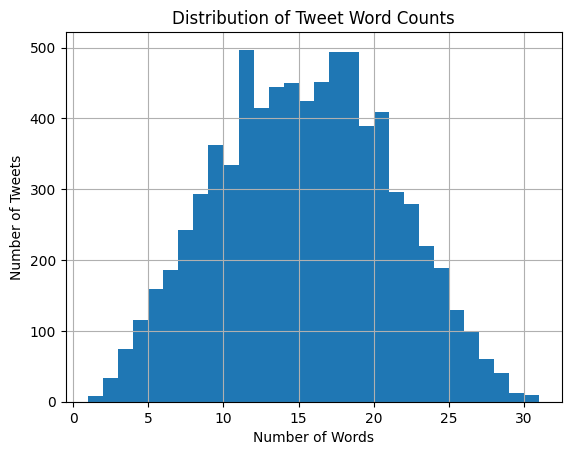

In [6]:
train_df['text'].apply(lambda x: len(str(x).split())).hist(bins=30)
plt.title('Distribution of Tweet Word Counts')
plt.xlabel('Number of Words')
plt.ylabel('Number of Tweets')
plt.show()

From the graph, the max number of words is about 32. So next I will tokenize the word.

In [7]:
# 1. Initialize the "Dictionary" (Limit to the top 10,000 words)
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train) # Learn words from training data only!

# 2. Convert words to numbers
train_sequences = tokenizer.texts_to_sequences(X_train)
val_sequences = tokenizer.texts_to_sequences(X_val)

# 3. Make every tweet exactly 35 numbers long
# We pad with zeros at the end ('post')
max_length = 35
X_train_ready = pad_sequences(train_sequences, maxlen=max_length, padding='pre', truncating='post')
X_val_ready = pad_sequences(val_sequences, maxlen=max_length, padding='pre', truncating='post')

## Baseline Model
This will be the model train with CNN

In [8]:
model = tf.keras.Sequential([
    layers.Embedding(10000, 16),
    layers.SpatialDropout1D(0.2), # Prevent word-feature memorization
    layers.Bidirectional(layers.LSTM(32, dropout=0.2, recurrent_dropout=0.2)),
    layers.Dense(24, activation='relu'),
    layers.Dropout(0.4), # Final shield against overfitting
    layers.Dense(1, activation='sigmoid')
])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

2026-03-14 07:39:31.069355: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [9]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(X_train_ready, y_train, epochs=10, validation_data=(X_val_ready, y_val), callbacks=[early_stop])

Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.5920 - loss: 0.6686 - val_accuracy: 0.7315 - val_loss: 0.5896
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.7894 - loss: 0.4816 - val_accuracy: 0.8024 - val_loss: 0.4492
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.8767 - loss: 0.3285 - val_accuracy: 0.7873 - val_loss: 0.4719
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.9059 - loss: 0.2659 - val_accuracy: 0.7892 - val_loss: 0.5371


In [10]:
# 1. Get probabilities
y_pred_probs = model.predict(X_val_ready)

# 2. Convert probabilities to binary (0 or 1) using a threshold
y_pred = (y_pred_probs > 0.3).astype("int32")

# 3. Calculate F1
f1 = f1_score(y_val, y_pred)
print(f"F1 Score: {f1:.4f}")
print(classification_report(y_val, y_pred, target_names=['Not Disaster', 'Disaster']))

48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step
F1 Score: 0.7516
              precision    recall  f1-score   support

Not Disaster       0.81      0.84      0.82       869
    Disaster       0.77      0.73      0.75       654

    accuracy                           0.79      1523
   macro avg       0.79      0.78      0.79      1523
weighted avg       0.79      0.79      0.79      1523



In [11]:
# Find indices where it was a Disaster (1) but we predicted Not Disaster (0)
false_negatives = (y_val == 1) & (y_pred.flatten() == 0)

# Show the first 5 missed disasters
missed_tweets = X_val[false_negatives].iloc[:5]
for tweet in missed_tweets:
    print(f"MISSING DISASTER: {tweet}\n")

MISSING DISASTER: ok peace I hope I fall off a cliff along with my dignity

MISSING DISASTER: TWIA board approves 5 percent rate hike: The Texas Windstorm Insurance Association (TWIA) Board of Directors v... http://t.co/TWPl0NL8cx

MISSING DISASTER: How long O Lord (Study 3)
 The sixth seal opens the events of Revelation 12. The political upheaval in the Roman... http://t.co/GW0CXoOJyV

MISSING DISASTER: Thunder pounds north goes black
a deep bruise on the sky's chest
wind cries its pain.  
A summer storm has a tough life
short violent.

MISSING DISASTER: Aquarium Ornament Wreck Sailing Boat Sunk Ship Destroyer Fish Tank Cave Decor - Full read Û_ http://t.co/kNCm9jC8i9 http://t.co/swviAZSPHk



## Improve the model
Now since I already have the baseline model, I will try to improve it. From the missing disaster, I think that the vocabulary of the model is not enough. So I will use the **GloVe** a pre-trained dictionary.

In [12]:
glove_path = '/kaggle/input/datasets/yesornope/glove6b/glove.6B.100d.txt'
embeddings_index = {}
with open(glove_path, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f'Found {len(embeddings_index)} word vectors.')

Found 400001 word vectors.


In [13]:
embedding_dim = 100 # Match the GloVe file dimension
word_index = tokenizer.word_index
num_words = min(10000, len(word_index) + 1)
embedding_matrix = np.zeros((num_words, embedding_dim))

for word, i in word_index.items():
    if i < 10000:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            # Words not found in embedding index will be all-zeros.
            embedding_matrix[i] = embedding_vector

In [22]:
model_v2 = tf.keras.Sequential([
    layers.Embedding(num_words, 
                     embedding_dim, 
                     embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
                     trainable=False), # Freeze the "dictionary" first
    layers.SpatialDropout1D(0.2),
    layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
    layers.GlobalMaxPool1D(), # Picks out the most "intense" signals from the LSTM
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])
model_v2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [23]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model_v2.fit(X_train_ready, y_train, epochs=10, validation_data=(X_val_ready, y_val), callbacks=[early_stop])

Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.7071 - loss: 0.5789 - val_accuracy: 0.7971 - val_loss: 0.4442
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.8041 - loss: 0.4517 - val_accuracy: 0.7971 - val_loss: 0.4474
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.7936 - loss: 0.4633 - val_accuracy: 0.8070 - val_loss: 0.4377
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.8063 - loss: 0.4365 - val_accuracy: 0.8096 - val_loss: 0.4263
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.8300 - loss: 0.4050 - val_accuracy: 0.8096 - val_loss: 0.4354
Epoch 6/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.8247 - loss: 0.4111 - val_accuracy: 0.7925 - val_loss: 0.4634
Epoch 7/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.8393 - loss: 0.3937 - val_accuracy: 0.8037 - val_loss: 0.4348


In [24]:
model_v2.layers[0].trainable = True
model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history_finetune = model_v2.fit(
    X_train_ready, 
    y_train,
    epochs=5, 
    validation_data=(X_val_ready, y_val),
    callbacks=[early_stop]
)

Epoch 1/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.8195 - loss: 0.4065 - val_accuracy: 0.8142 - val_loss: 0.4266
Epoch 2/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.8197 - loss: 0.4115 - val_accuracy: 0.8142 - val_loss: 0.4264
Epoch 3/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.8186 - loss: 0.4085 - val_accuracy: 0.8148 - val_loss: 0.4265
Epoch 4/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.8225 - loss: 0.4051 - val_accuracy: 0.8142 - val_loss: 0.4254
Epoch 5/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.8229 - loss: 0.3987 - val_accuracy: 0.8148 - val_loss: 0.4250


In [32]:
y_pred_probs = model_v2.predict(X_val_ready)

y_pred = (y_pred_probs > 0.5).astype("int32")

# 3. Calculate F1
f1 = f1_score(y_val, y_pred)
print(f"F1 Score: {f1:.4f}")
print(classification_report(y_val, y_pred, target_names=['Not Disaster', 'Disaster']))

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
F1 Score: 0.7606
              precision    recall  f1-score   support

Not Disaster       0.79      0.91      0.85       869
    Disaster       0.85      0.69      0.76       654

    accuracy                           0.81      1523
   macro avg       0.82      0.80      0.80      1523
weighted avg       0.82      0.81      0.81      1523



In [37]:
# 1. Get the raw probabilities from your fine-tuned model
y_probs = model_v2.predict(X_val_ready)

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []

# 2. Test each threshold
for t in thresholds:
    y_pred = (y_probs > t).astype(int)
    f1_scores.append(f1_score(y_val, y_pred))

# 3. Find the winner
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print(f"Optimal Threshold: {best_threshold:.2f}")
print(f"Best F1 Score: {best_f1:.4f}")

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Optimal Threshold: 0.36
Best F1 Score: 0.7631


## DistilBert

In [45]:
!pip install -q transformers datasets

In [42]:
from transformers import AutoTokenizer, DataCollatorWithPadding, DistilBertTokenizerFast

In [43]:
model_name = "distilbert-base-uncased"
tokenizer = DistilBertTokenizerFast.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

train_ds = Dataset.from_pandas(pd.DataFrame({'text': X_train, 'label': y_train}))
val_ds = Dataset.from_pandas(pd.DataFrame({'text': X_val, 'label': y_val}))

tokenized_train = train_ds.map(tokenize_function, batched=True)
tokenized_val = val_ds.map(tokenize_function, batched=True)

'[Errno -3] Temporary failure in name resolution' thrown while requesting HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].


RuntimeError: Cannot send a request, as the client has been closed.

In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

# 1. Load the Pre-trained Model with 2 labels (Disaster or Not)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# 2. Define the Evaluation Metric (F1 Score)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"f1": f1_score(labels, predictions)}

# 3. Set Training Parameters
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5, # Super small
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

# 4. The Trainer (The "Hyperbolic Time Chamber")
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()

## Submit the result

In [18]:
test_df = pd.read_csv("/kaggle/input/competitions/nlp-getting-started/test.csv")

X_test= test_df["text"]
test_sequences = tokenizer.texts_to_sequences(X_test)
X_test_ready = pad_sequences(test_sequences, maxlen=max_length, padding='pre', truncating='post')
prediction_probs = model_v2.predict(X_test_ready)
prediction = (prediction_probs > 0.3).astype("int32").flatten()

submission = pd.DataFrame({
    "id": test_df["id"],
    "target": prediction
})
submission.to_csv("submission.csv", index=False)

102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
